## Abstract for Spring into Research Sympiosum

## **PREDICTING MENTAL DISTRESS USING DEPRESSION AND FINANCIAL STRESS AMONG ADULTS IN THE UNITED STATES**
Mingma Lama, Daniel Owolabi, Radhouane Chouchane
Morgan State University, Department of Computer Science, Balitmore, MD 21251.

Mental distress is a major public health concern in the United States, affecting millions of adults and burdening healthcare systems nationwide. While depression is a well-established predictor of adverse mental health outcomes, the role of economic hardship in causing mental distress in adults remains underexplored in predictive modeling contexts. However, most existing approaches examine these factors in isolation. This study investigates whether combining depression and financial stress produces a stronger predictive model for frequent mental distress at the state level. It was hypothesized that states with higher rates of depression and financial stress would show higher rates of mental distress. State-level crude prevalence data from 50 U.S. states and the District of Columbia was used for analysis, along with a national aggregate estimate, with 41 observations used for training and 11 for testing. A composite variable called financial threat was constructed by combining housing insecurity, food insecurity, utility shut-off risk, and food stamp usage. A linear regression model was developed, producing the equation: Mental Distress = 6.163 + (0.313 × Depression) + (0.277 × Financial Threat). Results showed that both predictors were positively associated with mental distress. The model achieved an R² of 0.72, with a Root Mean Squared Error of 0.53, indicating that predicted values closely matched actual state-level mental distress rates. These findings confirm that integrating psychological and economic indicators improves prediction of mental health outcomes and can help public health agencies identify high-risk states and allocate resources more effectively.
Grant support: None





Fo this state-levelresearch we will be grouping by State- This is for Spring into research.

For

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor



In [ ]:
d = "/content/drive/MyDrive/Social_works_project/PLACES__Local_Data_for_Better_Health__County_Data__2025_release.csv"
da = pd.read_csv(d, low_memory=False)
da

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
0,2023,AR,Arkansas,Drew,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,29.9,...,26.6,33.3,16945,13230,5043,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-91.7196579038053 33.5894113647675)
1,2023,AR,Arkansas,Fulton,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,10.6,...,9.2,11.9,12421,9795,5049,HLTHOUT,CASTHMA,CrdPrv,Current Asthma,POINT (-91.817888079321 36.3816206347765)
2,2023,AR,Arkansas,Howard,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,31.2,...,27.7,34.8,12533,9311,5061,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-93.9938053308515 34.0889044688856)
3,2023,AR,Arkansas,Miller,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,4.7,...,4.2,5.3,42415,32396,5091,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-93.8924281761086 33.3123156126392)
4,2023,AR,Arkansas,Ouachita,BRFSS,Disability,Any disability among adults,%,Crude prevalence,42.8,...,37.9,47.8,21793,16948,5103,DISABLT,DISABILITY,CrdPrv,Any Disability,POINT (-92.882040791321 33.593253927504)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229293,2022,WA,Washington,Pacific,BRFSS,Prevention,Mammography use among women aged 50-74 years,%,Age-adjusted prevalence,71.7,...,64.8,78.5,24200,20677,53049,PREVENT,MAMMOUSE,AgeAdjPrv,Mammography,POINT (-123.705526977151 46.5554327139802)
229294,2023,WI,Wisconsin,Douglas,BRFSS,Health Outcomes,High blood pressure among adults,%,Crude prevalence,35.5,...,31.5,39.6,44264,35947,55031,HLTHOUT,BPHIGH,CrdPrv,High Blood Pressure,POINT (-91.9161252265845 46.4328926127271)
229295,2023,WI,Wisconsin,Door,BRFSS,Health Outcomes,High blood pressure among adults,%,Age-adjusted prevalence,27.9,...,24.3,31.5,30562,25848,55029,HLTHOUT,BPHIGH,AgeAdjPrv,High Blood Pressure,POINT (-87.3114193001272 44.9500144269812)
229296,2023,WV,West Virginia,Gilmer,BRFSS,Health Risk Behaviors,No leisure-time physical activity among adults,%,Crude prevalence,34.8,...,29.0,40.7,7254,6147,54021,RISKBEH,LPA,CrdPrv,Physical Inactivity,POINT (-80.8565551863755 38.9243479452265)


In [ ]:
da.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229298 entries, 0 to 229297
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Year                        229298 non-null  int64  
 1   StateAbbr                   229298 non-null  object 
 2   StateDesc                   229298 non-null  object 
 3   LocationName                229218 non-null  object 
 4   DataSource                  229298 non-null  object 
 5   Category                    229298 non-null  object 
 6   Measure                     229298 non-null  object 
 7   Data_Value_Unit             229298 non-null  object 
 8   Data_Value_Type             229298 non-null  object 
 9   Data_Value                  229232 non-null  float64
 10  Data_Value_Footnote_Symbol  80 non-null      object 
 11  Data_Value_Footnote         80 non-null      object 
 12  Low_Confidence_Limit        229232 non-null  float64
 13  High_Confidenc

In [ ]:
(da.isnull().sum()/len(da))

,0
Year,0.000000
StateAbbr,0.000000
StateDesc,0.000000
LocationName,0.000349
DataSource,0.000000
Category,0.000000
Measure,0.000000
Data_Value_Unit,0.000000
Data_Value_Type,0.000000
Data_Value,0.000288


In [ ]:
(da.isnull(). sum()/ len(da)) * 100

,0
Year,0.000000
StateAbbr,0.000000
StateDesc,0.000000
LocationName,0.034889
DataSource,0.000000
Category,0.000000
Measure,0.000000
Data_Value_Unit,0.000000
Data_Value_Type,0.000000
Data_Value,0.028784


In [ ]:
da.columns
da.head()

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
0,2023,AR,Arkansas,Drew,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,29.9,...,26.6,33.3,16945,13230,5043,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-91.7196579038053 33.5894113647675)
1,2023,AR,Arkansas,Fulton,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,10.6,...,9.2,11.9,12421,9795,5049,HLTHOUT,CASTHMA,CrdPrv,Current Asthma,POINT (-91.817888079321 36.3816206347765)
2,2023,AR,Arkansas,Howard,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,31.2,...,27.7,34.8,12533,9311,5061,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-93.9938053308515 34.0889044688856)
3,2023,AR,Arkansas,Miller,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,4.7,...,4.2,5.3,42415,32396,5091,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-93.8924281761086 33.3123156126392)
4,2023,AR,Arkansas,Ouachita,BRFSS,Disability,Any disability among adults,%,Crude prevalence,42.8,...,37.9,47.8,21793,16948,5103,DISABLT,DISABILITY,CrdPrv,Any Disability,POINT (-92.882040791321 33.593253927504)


In [ ]:
da.columns


Index(['Year', 'StateAbbr', 'StateDesc', 'LocationName', 'DataSource',
       'Category', 'Measure', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote',
       'Low_Confidence_Limit', 'High_Confidence_Limit', 'TotalPopulation',
       'TotalPop18plus', 'LocationID', 'CategoryID', 'MeasureId',
       'DataValueTypeID', 'Short_Question_Text', 'Geolocation'],
      dtype='object')

In [ ]:
da.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229298 entries, 0 to 229297
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Year                        229298 non-null  int64  
 1   StateAbbr                   229298 non-null  object 
 2   StateDesc                   229298 non-null  object 
 3   LocationName                229218 non-null  object 
 4   DataSource                  229298 non-null  object 
 5   Category                    229298 non-null  object 
 6   Measure                     229298 non-null  object 
 7   Data_Value_Unit             229298 non-null  object 
 8   Data_Value_Type             229298 non-null  object 
 9   Data_Value                  229232 non-null  float64
 10  Data_Value_Footnote_Symbol  80 non-null      object 
 11  Data_Value_Footnote         80 non-null      object 
 12  Low_Confidence_Limit        229232 non-null  float64
 13  High_Confidenc

In [ ]:
da["Measure"].unique()

array(['Arthritis among adults', 'Current asthma among adults',
       'Stroke among adults', 'Any disability among adults',
       'Obesity among adults', 'Diagnosed diabetes among adults',
       'Depression among adults', 'Hearing disability among adults',
       'Binge drinking among adults', 'High blood pressure among adults',
       'Vision disability among adults',
       'Mobility disability among adults',
       'Self-care disability among adults',
       'Frequent mental distress among adults',
       'High cholesterol among adults who have ever been screened',
       'Frequent physical distress among adults',
       'Colorectal cancer screening among adults aged 45–75 years',
       'No leisure-time physical activity among adults',
       'Chronic obstructive pulmonary disease among adults',
       'Independent living disability among adults',
       'Coronary heart disease among adults',
       'Mammography use among women aged 50-74 years',
       'Visits to doctor for rou

In [ ]:
selected_measures = [
    'Obesity among adults',
    'Diagnosed diabetes among adults',
    'High blood pressure among adults',
    'Lack of social and emotional support among adults',
    'Current cigarette smoking among adults',
    'Housing insecurity in the past 12 months among adults',

]

In [ ]:
da['Measure']

,Measure
0,Arthritis among adults
1,Current asthma among adults
2,Arthritis among adults
3,Stroke among adults
4,Any disability among adults
...,...
229293,Mammography use among women aged 50-74 years
229294,High blood pressure among adults
229295,High blood pressure among adults
229296,No leisure-time physical activity among adults


In [ ]:
da_filtered = da[da['Measure'].isin(selected_measures)]
da_filtered

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
12,2023,CO,Colorado,Yuma,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,28.4,...,21.5,36.2,9862,7075,8125,HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-102.424564854412 40.0028209513012)
13,2023,FL,Florida,Brevard,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,Crude prevalence,13.1,...,11.3,15.2,643979,528274,12009,HLTHOUT,DIABETES,CrdPrv,Diabetes,POINT (-80.7322290402972 28.2934562139849)
14,2023,FL,Florida,Citrus,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,Crude prevalence,15.8,...,13.4,18.1,166696,142235,12017,HLTHOUT,DIABETES,CrdPrv,Diabetes,POINT (-82.4772202477587 28.8485262076997)
20,2023,GA,Georgia,Catoosa,BRFSS,Health Outcomes,Obesity among adults,%,Age-adjusted prevalence,33.9,...,27.1,41.7,68910,54038,13047,HLTHOUT,OBESITY,AgeAdjPrv,Obesity,POINT (-85.1386810142994 34.9040327945415)
25,2023,GA,Georgia,Peach,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,39.3,...,31.1,47.7,28805,22815,13225,HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-83.8278402405427 32.5679570126366)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229274,2023,WA,Washington,Garfield,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,Age-adjusted prevalence,8.3,...,7.1,9.6,2363,1865,53023,HLTHOUT,DIABETES,AgeAdjPrv,Diabetes,POINT (-117.544668771271 46.4315035506264)
229281,2023,WV,West Virginia,Mason,BRFSS,Health Outcomes,High blood pressure among adults,%,Age-adjusted prevalence,38.6,...,34.3,43.0,24765,19716,54053,HLTHOUT,BPHIGH,AgeAdjPrv,High Blood Pressure,POINT (-82.0265180831264 38.7697766470729)
229287,2023,WI,Wisconsin,Iron,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,Age-adjusted prevalence,9.6,...,8.2,11.1,6228,5234,55051,HLTHOUT,DIABETES,AgeAdjPrv,Diabetes,POINT (-90.2421159937405 46.2623105163576)
229294,2023,WI,Wisconsin,Douglas,BRFSS,Health Outcomes,High blood pressure among adults,%,Crude prevalence,35.5,...,31.5,39.6,44264,35947,55031,HLTHOUT,BPHIGH,CrdPrv,High Blood Pressure,POINT (-91.9161252265845 46.4328926127271)


In [ ]:
da_filtered = da_filtered[
    da_filtered["Data_Value_Type"] == "Crude prevalence"
]
da_filtered

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
12,2023,CO,Colorado,Yuma,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,28.4,...,21.5,36.2,9862,7075,8125,HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-102.424564854412 40.0028209513012)
13,2023,FL,Florida,Brevard,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,Crude prevalence,13.1,...,11.3,15.2,643979,528274,12009,HLTHOUT,DIABETES,CrdPrv,Diabetes,POINT (-80.7322290402972 28.2934562139849)
14,2023,FL,Florida,Citrus,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,Crude prevalence,15.8,...,13.4,18.1,166696,142235,12017,HLTHOUT,DIABETES,CrdPrv,Diabetes,POINT (-82.4772202477587 28.8485262076997)
25,2023,GA,Georgia,Peach,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,39.3,...,31.1,47.7,28805,22815,13225,HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-83.8278402405427 32.5679570126366)
29,2023,GA,Georgia,Twiggs,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,39.7,...,31.3,48.1,7691,6243,13289,HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-83.4270456679841 32.6669819807256)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229214,2023,WV,West Virginia,Monroe,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,41.1,...,32.7,50.0,12382,9940,54063,HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-80.5505495429756 37.5604387985945)
229232,2023,WI,Wisconsin,Chippewa,BRFSS,Health-Related Social Needs,Housing insecurity in the past 12 months among...,%,Crude prevalence,9.1,...,7.4,11.1,66970,52829,55017,SOCLNEED,HOUSINSECU,CrdPrv,Housing Insecurity,POINT (-91.2799726300936 45.0694319590576)
229238,2023,WI,Wisconsin,Langlade,BRFSS,Health Outcomes,High blood pressure among adults,%,Crude prevalence,39.2,...,35.0,43.2,19404,15739,55067,HLTHOUT,BPHIGH,CrdPrv,High Blood Pressure,POINT (-89.0718838982873 45.2623121759565)
229273,2023,WY,Wyoming,Teton,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,24.0,...,18.7,30.1,23232,19340,56039,HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-110.589857877684 43.9344840596924)


In [ ]:
md_data = da_filtered[da_filtered["StateAbbr"] == "MD"]
md_data

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
72183,2023,MD,Maryland,Baltimore,BRFSS,Health-Related Social Needs,Housing insecurity in the past 12 months among...,%,Crude prevalence,13.7,...,11.6,16.2,844703,661546,24005,SOCLNEED,HOUSINSECU,CrdPrv,Housing Insecurity,POINT (-76.635956565388 39.4596984571411)
72215,2023,MD,Maryland,Wicomico,BRFSS,Health-Related Social Needs,Housing insecurity in the past 12 months among...,%,Crude prevalence,13.4,...,11.2,15.4,104800,81312,24045,SOCLNEED,HOUSINSECU,CrdPrv,Housing Insecurity,POINT (-75.6215195926947 38.3727886353365)
72240,2023,MD,Maryland,Charles,BRFSS,Health-Related Social Needs,Lack of social and emotional support among adults,%,Crude prevalence,27.1,...,23.8,30.9,171973,131229,24017,SOCLNEED,EMOTIONSPT,CrdPrv,Lack of Social/Emotional Support,POINT (-76.9921815094734 38.5069477200876)
72625,2023,MD,Maryland,Harford,BRFSS,Health-Related Social Needs,Lack of social and emotional support among adults,%,Crude prevalence,21.4,...,18.2,24.7,264644,206050,24025,SOCLNEED,EMOTIONSPT,CrdPrv,Lack of Social/Emotional Support,POINT (-76.3169029187153 39.5614247093358)
72668,2023,MD,Maryland,Caroline,BRFSS,Health Outcomes,High blood pressure among adults,%,Crude prevalence,41.3,...,37.6,45.0,33593,25618,24011,HLTHOUT,BPHIGH,CrdPrv,High Blood Pressure,POINT (-75.8321719815862 38.8720440517484)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89539,2023,MD,Maryland,Prince George's,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,Crude prevalence,15.2,...,13.5,16.9,947430,740721,24033,HLTHOUT,DIABETES,CrdPrv,Diabetes,POINT (-76.8475085634277 38.8296511376687)
89650,2023,MD,Maryland,Montgomery,BRFSS,Health Outcomes,High blood pressure among adults,%,Crude prevalence,32.7,...,30.3,35.2,1058474,819715,24031,HLTHOUT,BPHIGH,CrdPrv,High Blood Pressure,POINT (-77.2047730488674 39.1362604928732)
89729,2023,MD,Maryland,Frederick,BRFSS,Health-Related Social Needs,Housing insecurity in the past 12 months among...,%,Crude prevalence,10.0,...,8.4,11.8,293391,224828,24021,SOCLNEED,HOUSINSECU,CrdPrv,Housing Insecurity,POINT (-77.3976709371378 39.47221383853)
89866,2023,MD,Maryland,Howard,BRFSS,Health-Related Social Needs,Housing insecurity in the past 12 months among...,%,Crude prevalence,8.7,...,7.2,10.4,336001,256944,24027,SOCLNEED,HOUSINSECU,CrdPrv,Housing Insecurity,POINT (-76.9308970282026 39.2502169624857)


In [ ]:
baltimore_data = md_data[md_data["LocationName"] == "Baltimore"]
baltimore_data

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
72183,2023,MD,Maryland,Baltimore,BRFSS,Health-Related Social Needs,Housing insecurity in the past 12 months among...,%,Crude prevalence,13.7,...,11.6,16.2,844703,661546,24005,SOCLNEED,HOUSINSECU,CrdPrv,Housing Insecurity,POINT (-76.635956565388 39.4596984571411)
72955,2023,MD,Maryland,Baltimore,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,Crude prevalence,14.4,...,12.8,16.3,565239,447486,24510,HLTHOUT,DIABETES,CrdPrv,Diabetes,POINT (-76.6144656268901 39.3051294208208)
73214,2023,MD,Maryland,Baltimore,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,38.7,...,34.6,43.4,565239,447486,24510,HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-76.6144656268901 39.3051294208208)
73919,2023,MD,Maryland,Baltimore,BRFSS,Health Risk Behaviors,Current cigarette smoking among adults,%,Crude prevalence,11.1,...,9.2,13.3,844703,661546,24005,RISKBEH,CSMOKING,CrdPrv,Current Cigarette Smoking,POINT (-76.635956565388 39.4596984571411)
74069,2023,MD,Maryland,Baltimore,BRFSS,Health-Related Social Needs,Lack of social and emotional support among adults,%,Crude prevalence,28.5,...,24.8,32.3,565239,447486,24510,SOCLNEED,EMOTIONSPT,CrdPrv,Lack of Social/Emotional Support,POINT (-76.6144656268901 39.3051294208208)
74852,2023,MD,Maryland,Baltimore,BRFSS,Health Outcomes,High blood pressure among adults,%,Crude prevalence,36.7,...,34.1,39.1,844703,661546,24005,HLTHOUT,BPHIGH,CrdPrv,High Blood Pressure,POINT (-76.635956565388 39.4596984571411)
77245,2023,MD,Maryland,Baltimore,BRFSS,Health-Related Social Needs,Housing insecurity in the past 12 months among...,%,Crude prevalence,21.4,...,17.9,25.2,565239,447486,24510,SOCLNEED,HOUSINSECU,CrdPrv,Housing Insecurity,POINT (-76.6144656268901 39.3051294208208)
82003,2023,MD,Maryland,Baltimore,BRFSS,Health-Related Social Needs,Lack of social and emotional support among adults,%,Crude prevalence,25.6,...,22.5,29.0,844703,661546,24005,SOCLNEED,EMOTIONSPT,CrdPrv,Lack of Social/Emotional Support,POINT (-76.635956565388 39.4596984571411)
83583,2023,MD,Maryland,Baltimore,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,34.0,...,30.5,37.5,844703,661546,24005,HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-76.635956565388 39.4596984571411)
84513,2023,MD,Maryland,Baltimore,BRFSS,Health Risk Behaviors,Current cigarette smoking among adults,%,Crude prevalence,15.8,...,13.1,18.9,565239,447486,24510,RISKBEH,CSMOKING,CrdPrv,Current Cigarette Smoking,POINT (-76.6144656268901 39.3051294208208)


In [ ]:
da_filtered.duplicated(subset=['StateAbbr','LocationName','Year','Measure']).sum()

np.int64(36)

In [ ]:
summary = pd.DataFrame({
    "dtype": da.dtypes,
    "missing_count": da.isnull().sum(),
    "missing_percent": (da.isnull().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=True)
summary.head(50)




,dtype,missing_count,missing_percent
Year,int64,0,0.00
StateAbbr,object,0,0.00
StateDesc,object,0,0.00
DataSource,object,0,0.00
Measure,object,0,0.00
Category,object,0,0.00
Data_Value_Unit,object,0,0.00
Data_Value_Type,object,0,0.00
TotalPopulation,int64,0,0.00
TotalPop18plus,int64,0,0.00


In [ ]:
summary.describe()


,missing_count,missing_percent
count,22.000000,22.000000
mean,20854.272727,9.095000
std,67440.977269,29.413463
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,66.000000,0.030000
max,229218.000000,99.970000


In [ ]:
da_wide =  md_data.pivot_table(
    index=["StateAbbr", "Year", "LocationName", "TotalPopulation", "TotalPop18plus"],
    columns="Measure",
    values="Data_Value",
    aggfunc="mean"
).reset_index()
da_wide

Measure,StateAbbr,Year,LocationName,TotalPopulation,TotalPop18plus,Current cigarette smoking among adults,Diagnosed diabetes among adults,High blood pressure among adults,Housing insecurity in the past 12 months among adults,Lack of social and emotional support among adults,Obesity among adults
0,MD,2023,Allegany,67273,55228,17.7,13.3,39.6,13.6,25.0,36.6
1,MD,2023,Anne Arundel,594582,461032,10.6,10.4,34.5,10.4,22.0,34.5
2,MD,2023,Baltimore,565239,447486,15.8,14.4,40.6,21.4,28.5,38.7
3,MD,2023,Baltimore,844703,661546,11.1,13.1,36.7,13.7,25.6,34.0
4,MD,2023,Calvert,94728,72945,11.1,10.9,36.9,10.0,21.4,36.3
5,MD,2023,Caroline,33593,25618,17.4,14.2,41.3,15.2,24.6,41.7
6,MD,2023,Carroll,176639,137462,10.9,10.3,34.4,8.4,19.7,37.7
7,MD,2023,Cecil,105672,82332,15.3,13.2,39.2,11.4,21.8,41.3
8,MD,2023,Charles,171973,131229,11.5,13.4,41.4,15.0,27.1,41.9
9,MD,2023,Dorchester,32879,26096,16.1,16.6,44.2,15.6,24.9,41.8


In [ ]:
md_data["Data_Value_Unit"].unique()

array(['%'], dtype=object)

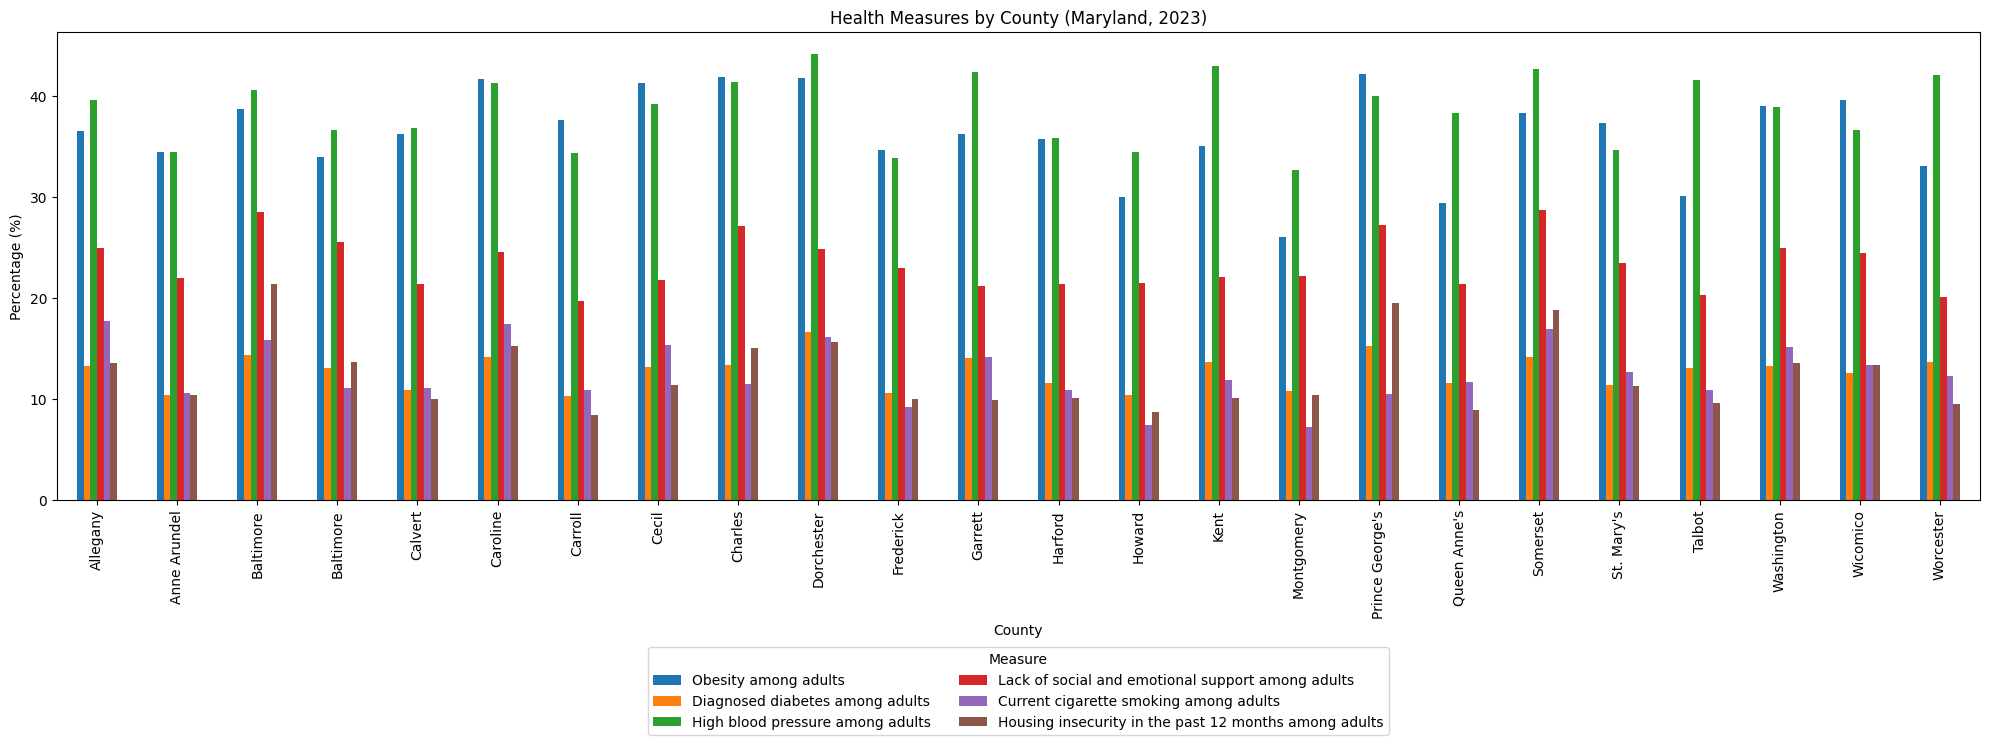

In [ ]:
measure_columns = [
    "Obesity among adults",
    "Diagnosed diabetes among adults",
    "High blood pressure among adults",
    "Lack of social and emotional support among adults",
    "Current cigarette smoking among adults",
    "Housing insecurity in the past 12 months among adults",

]
plot_data = da_wide.set_index("LocationName")[measure_columns]

plot_data.plot(kind="bar", figsize=(20,8))

plt.xlabel("County")
plt.ylabel("Percentage (%)")
plt.title("Health Measures by County (Maryland, 2023)")
plt.xticks(rotation=90)
plt.legend(title="Measure", bbox_to_anchor=(0.5, -0.3), loc="upper center", ncol=2)
plt.tight_layout()
plt.show()



In [ ]:
selected_measures = [
    "Stroke among adults",
    "High blood pressure among adults",
    "Current cigarette smoking among adults",
    "Diagnosed diabetes among adults",
    "High cholesterol among adults who have ever been screened",
    "Obesity among adults",
    "No leisure-time physical activity among adults",
    "Coronary heart disease among adults",
    "Binge drinking among adults"
]
da_filtered = da[da["Measure"].isin(selected_measures)]
da_filtered = da_filtered[da_filtered["Data_Value_Type"] == "Crude prevalence"]
da_filtered

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
3,2023,AR,Arkansas,Miller,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,4.7,...,4.2,5.3,42415,32396,5091,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-93.8924281761086 33.3123156126392)
5,2023,AR,Arkansas,Pulaski,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,3.9,...,3.4,4.3,400009,307397,5119,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-92.3119548341849 34.7700394452014)
6,2023,AR,Arkansas,Van Buren,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,5.4,...,4.7,6.2,16142,13054,5141,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-92.5158922653774 35.5806118772188)
12,2023,CO,Colorado,Yuma,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,28.4,...,21.5,36.2,9862,7075,8125,HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-102.424564854412 40.0028209513012)
13,2023,FL,Florida,Brevard,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,Crude prevalence,13.1,...,11.3,15.2,643979,528274,12009,HLTHOUT,DIABETES,CrdPrv,Diabetes,POINT (-80.7322290402972 28.2934562139849)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229273,2023,WY,Wyoming,Teton,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,24.0,...,18.7,30.1,23232,19340,56039,HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-110.589857877684 43.9344840596924)
229288,2023,WI,Wisconsin,Milwaukee,BRFSS,Health Risk Behaviors,Binge drinking among adults,%,Crude prevalence,16.8,...,14.8,18.9,916205,700935,55079,RISKBEH,BINGE,CrdPrv,Binge Drinking,POINT (-87.9669491230639 43.0071720144533)
229289,2023,WV,West Virginia,Lincoln,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,5.1,...,4.5,5.7,19701,15393,54043,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-82.0709294651021 38.1746145924151)
229294,2023,WI,Wisconsin,Douglas,BRFSS,Health Outcomes,High blood pressure among adults,%,Crude prevalence,35.5,...,31.5,39.6,44264,35947,55031,HLTHOUT,BPHIGH,CrdPrv,High Blood Pressure,POINT (-91.9161252265845 46.4328926127271)


In [ ]:
pivot = da_filtered.pivot_table(
    index = "StateDesc",
    columns = "Measure",
    values = "Data_Value",
)
pivot

Measure,Binge drinking among adults,Coronary heart disease among adults,Current cigarette smoking among adults,Diagnosed diabetes among adults,High blood pressure among adults,High cholesterol among adults who have ever been screened,No leisure-time physical activity among adults,Obesity among adults,Stroke among adults
StateDesc,,,,,,,,,
Alabama,13.128358,8.495522,17.432836,16.802985,46.649254,42.347761,32.274627,41.726866,4.879104
Alaska,17.273333,7.013333,19.433333,11.570000,35.566667,34.806667,24.730000,35.730000,3.850000
Arizona,14.266667,8.013333,13.853333,13.393333,36.160000,37.813333,25.726667,32.873333,4.366667
Arkansas,13.622667,9.090667,18.068000,15.293333,45.172000,40.378667,36.034667,40.926667,4.790667
California,15.791379,6.775862,12.250000,12.062069,33.317241,36.153448,24.998276,29.765517,3.608621
Colorado,16.865625,6.859375,12.559375,10.617188,31.618750,34.604687,20.090625,27.110937,3.529688
Connecticut,15.544444,5.955556,10.844444,10.055556,32.533333,38.400000,25.000000,30.400000,3.255556
Delaware,13.633333,7.200000,13.033333,13.566667,39.366667,42.066667,28.333333,36.900000,3.866667
District of Columbia,23.400000,3.800000,9.400000,7.800000,28.500000,32.800000,14.900000,24.700000,2.800000


In [ ]:
factors = [

    "High blood pressure among adults",
    "Current cigarette smoking among adults",
    "Diagnosed diabetes among adults",
    "High cholesterol among adults who have ever been screened",
    "Obesity among adults",
    "No leisure-time physical activity among adults",
    "Coronary heart disease among adults",
    "Binge drinking among adults"
]

stroke_data = pivot[factors].corrwith(pivot["Stroke among adults"])
stroke_data

,0
Measure,
High blood pressure among adults,0.859562
Current cigarette smoking among adults,0.758106
Diagnosed diabetes among adults,0.916794
High cholesterol among adults who have ever been screened,0.594546
Obesity among adults,0.694305
No leisure-time physical activity among adults,0.782834
Coronary heart disease among adults,0.854793
Binge drinking among adults,-0.447767


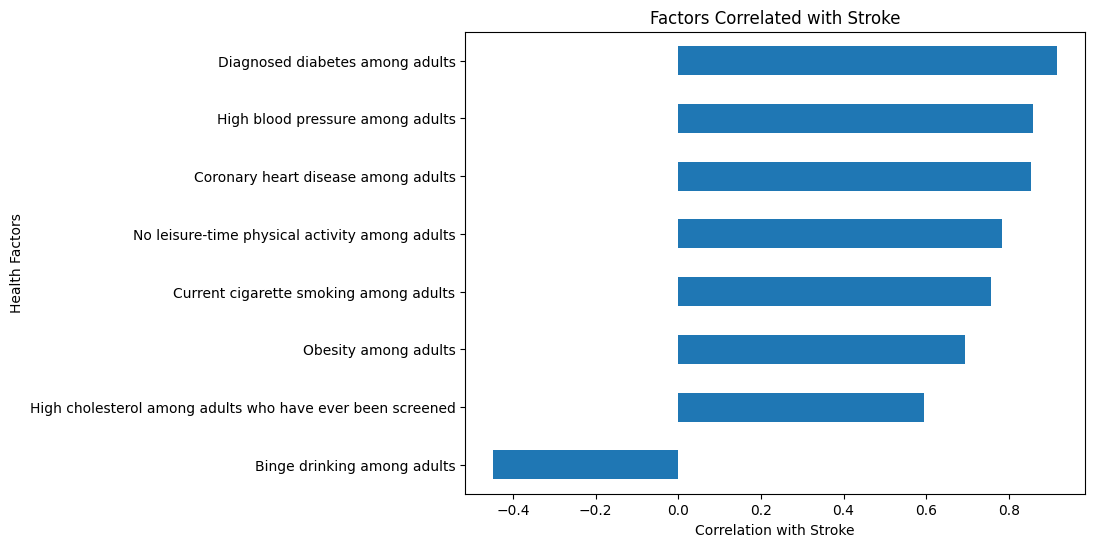

In [ ]:
stroke_data.sort_values().plot(kind="barh", figsize=(8,6))

plt.title("Factors Correlated with Stroke")
plt.xlabel("Correlation with Stroke")
plt.ylabel("Health Factors")

plt.show()

1. Diabetes has the strong realtionship with strokje as it is closer to 0.9, also with the high blood pressure and coronary heart disease. so states having high diabetes, high blood pressure, heart disease have higher stroke prevalence
2.lifestyle factors like smoking, pyhsical activity tends to affect stroke among adults.

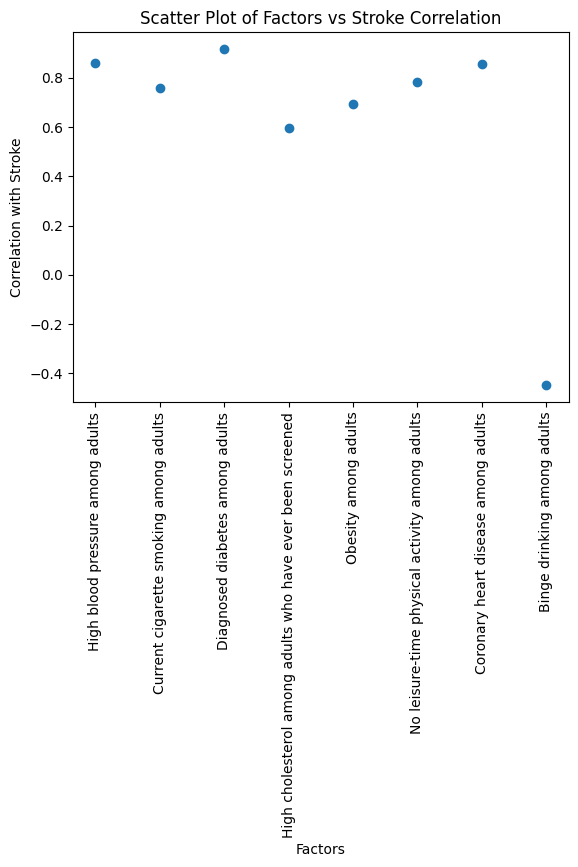

In [ ]:

plt.scatter(stroke_data.index, stroke_data.values)

plt.title("Scatter Plot of Factors vs Stroke Correlation")
plt.xlabel("Factors")
plt.ylabel("Correlation with Stroke")

plt.xticks(rotation=90)
plt.show()

In [ ]:
selected_measures2 = [
         "Depression among adults",
      "Housing insecurity in the past 12 months among adults",
      "Utility services shut-off threat in the past 12 months among adults",
       "Food insecurity in the past 12 months among adults",
       "Loneliness among adults",
       "Received food stamps in the past 12 months among adults",
       "Short sleep duration among adults",
         "Frequent mental distress among adults"


]
da_filtered2 = da[da["Measure"].isin(selected_measures2)]
da_filtered2 = da_filtered2[da_filtered2["Data_Value_Type"] == "Crude prevalence"]
da_filtered2

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
15,2023,FL,Florida,Flagler,BRFSS,Health Outcomes,Depression among adults,%,Crude prevalence,18.3,...,15.8,21.1,131439,110520,12035,HLTHOUT,DEPRESSION,CrdPrv,Depression,POINT (-81.3134845980192 29.4615154544014)
18,2023,FL,Florida,Seminole,BRFSS,Health Outcomes,Depression among adults,%,Crude prevalence,16.4,...,14.0,19.1,484271,385528,12117,HLTHOUT,DEPRESSION,CrdPrv,Depression,POINT (-81.235632248437 28.7167421000311)
31,2023,GA,Georgia,Wheeler,BRFSS,Health Outcomes,Depression among adults,%,Crude prevalence,19.0,...,16.0,22.3,7081,5935,13309,HLTHOUT,DEPRESSION,CrdPrv,Depression,POINT (-82.725207369526 32.1177472167522)
39,2023,IL,Illinois,Douglas,BRFSS,Health Outcomes,Depression among adults,%,Crude prevalence,22.6,...,19.0,26.7,19629,14859,17041,HLTHOUT,DEPRESSION,CrdPrv,Depression,POINT (-88.2172568038989 39.7694705783852)
52,2023,IA,Iowa,Fremont,BRFSS,Health Outcomes,Depression among adults,%,Crude prevalence,20.1,...,17.0,23.4,6458,5059,19071,HLTHOUT,DEPRESSION,CrdPrv,Depression,POINT (-95.6047023421803 40.7455695629106)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229232,2023,WI,Wisconsin,Chippewa,BRFSS,Health-Related Social Needs,Housing insecurity in the past 12 months among...,%,Crude prevalence,9.1,...,7.4,11.1,66970,52829,55017,SOCLNEED,HOUSINSECU,CrdPrv,Housing Insecurity,POINT (-91.2799726300936 45.0694319590576)
229268,2023,WV,West Virginia,Lewis,BRFSS,Health Status,Frequent mental distress among adults,%,Crude prevalence,21.6,...,18.8,24.5,16500,12975,54041,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress,POINT (-80.5022541227854 38.9959239226888)
229275,2023,WI,Wisconsin,Jackson,BRFSS,Health-Related Social Needs,Utility services shut-off threat in the past 1...,%,Crude prevalence,6.5,...,5.5,7.7,20855,16438,55053,SOCLNEED,SHUTUTILITY,CrdPrv,Utility Services Threat,POINT (-90.8049987126148 44.3192836652452)
229285,2023,WA,Washington,Spokane,BRFSS,Health Outcomes,Depression among adults,%,Crude prevalence,26.5,...,23.9,29.1,551455,433863,53063,HLTHOUT,DEPRESSION,CrdPrv,Depression,POINT (-117.404063103244 47.6206587768365)


In [ ]:
pivot_3 = da_filtered2.pivot_table(
    index = "LocationName",
    columns = "Measure",
    values = "Data_Value",
)
pivot_3

Measure,Depression among adults,Food insecurity in the past 12 months among adults,Frequent mental distress among adults,Housing insecurity in the past 12 months among adults,Loneliness among adults,Received food stamps in the past 12 months among adults,Short sleep duration among adults,Utility services shut-off threat in the past 12 months among adults
LocationName,,,,,,,,
Abbeville,23.2,20.600000,17.600000,14.400000,32.900000,13.300000,36.90,9.900000
Acadia,30.6,26.300000,21.600000,17.800000,36.600000,23.800000,37.30,13.400000
Accomack,21.7,19.000000,16.900000,14.300000,34.000000,17.900000,35.60,9.600000
Ada,25.0,9.900000,15.200000,8.600000,28.200000,6.400000,30.30,5.400000
Adair,24.7,18.766667,19.033333,13.566667,33.433333,15.933333,37.95,10.233333
...,...,...,...,...,...,...,...,...
Yukon-Koyukuk,19.8,29.600000,18.800000,21.200000,36.200000,22.400000,39.60,15.500000
Yuma,20.1,24.400000,16.100000,18.300000,33.100000,17.400000,33.15,10.300000
Zapata,20.4,NaN,18.800000,NaN,NaN,NaN,41.90,NaN


In [ ]:
pivot_2 = da_filtered2.pivot_table(
    index = "StateDesc",
    columns = "Measure",
    values = "Data_Value",
)
pivot_2

Measure,Depression among adults,Food insecurity in the past 12 months among adults,Frequent mental distress among adults,Housing insecurity in the past 12 months among adults,Loneliness among adults,Received food stamps in the past 12 months among adults,Short sleep duration among adults,Utility services shut-off threat in the past 12 months among adults
StateDesc,,,,,,,,
Alabama,23.628358,22.741791,17.976119,15.825373,35.859701,17.823881,40.546269,11.207463
Alaska,19.210000,18.716667,16.290000,14.550000,33.400000,13.306667,36.936667,10.096667
Arizona,19.780000,19.240000,16.206667,14.180000,31.646667,14.266667,35.826667,9.273333
Arkansas,24.661333,20.881333,18.990667,15.392000,34.713333,13.945333,39.705333,11.454667
California,21.868966,17.153448,17.101724,14.063793,35.093103,15.836207,34.277586,7.486207
Colorado,22.139063,NaN,15.860938,NaN,NaN,NaN,30.648438,NaN
Connecticut,21.088889,13.955556,15.800000,11.800000,32.411111,11.033333,35.411111,7.922222
Delaware,21.300000,14.100000,15.666667,11.633333,31.966667,12.033333,36.100000,7.466667
District of Columbia,21.600000,13.900000,14.100000,12.200000,37.000000,13.000000,32.800000,7.800000


In [ ]:
factors_three = [
      "Depression among adults",
      "Housing insecurity in the past 12 months among adults",
      "Utility services shut-off threat in the past 12 months among adults",
       "Food insecurity in the past 12 months among adults",
       "Loneliness among adults",
       "Received food stamps in the past 12 months among adults",
       "Short sleep duration among adults"


]

mentalh_data_2 = pivot_3[factors_three].corrwith(pivot_3["Frequent mental distress among adults"])
mentalh_data_2

,0
Measure,
Depression among adults,0.599813
Housing insecurity in the past 12 months among adults,0.632289
Utility services shut-off threat in the past 12 months among adults,0.707013
Food insecurity in the past 12 months among adults,0.647361
Loneliness among adults,0.686903
Received food stamps in the past 12 months among adults,0.687392
Short sleep duration among adults,0.666675


In [ ]:
factors_two = [
      "Depression among adults",
      "Housing insecurity in the past 12 months among adults",
      "Utility services shut-off threat in the past 12 months among adults",
       "Food insecurity in the past 12 months among adults",
       "Loneliness among adults",
       "Received food stamps in the past 12 months among adults",
       "Short sleep duration among adults"


]

mentalh_data = pivot_2[factors_two].corrwith(pivot_2["Frequent mental distress among adults"])
mentalh_data

,0
Measure,
Depression among adults,0.691037
Housing insecurity in the past 12 months among adults,0.493102
Utility services shut-off threat in the past 12 months among adults,0.688441
Food insecurity in the past 12 months among adults,0.506442
Loneliness among adults,0.515358
Received food stamps in the past 12 months among adults,0.613444
Short sleep duration among adults,0.568687


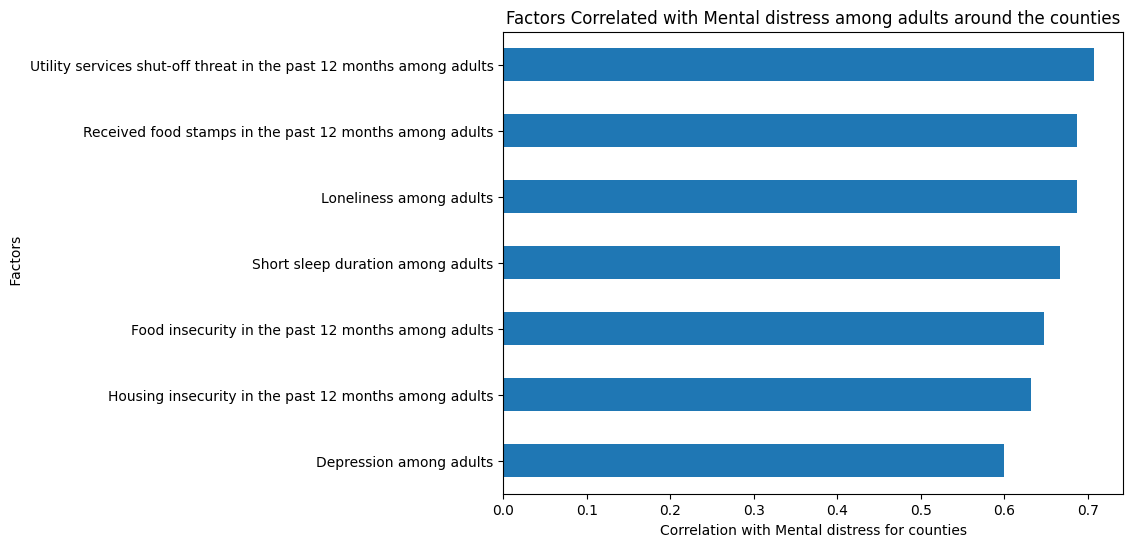

In [ ]:
mentalh_data_2.sort_values().plot(kind="barh", figsize=(8,6))

plt.title("Factors Correlated with Mental distress among adults around the counties")
plt.xlabel("Correlation with Mental distress for counties")
plt.ylabel(" Factors")

plt.show()

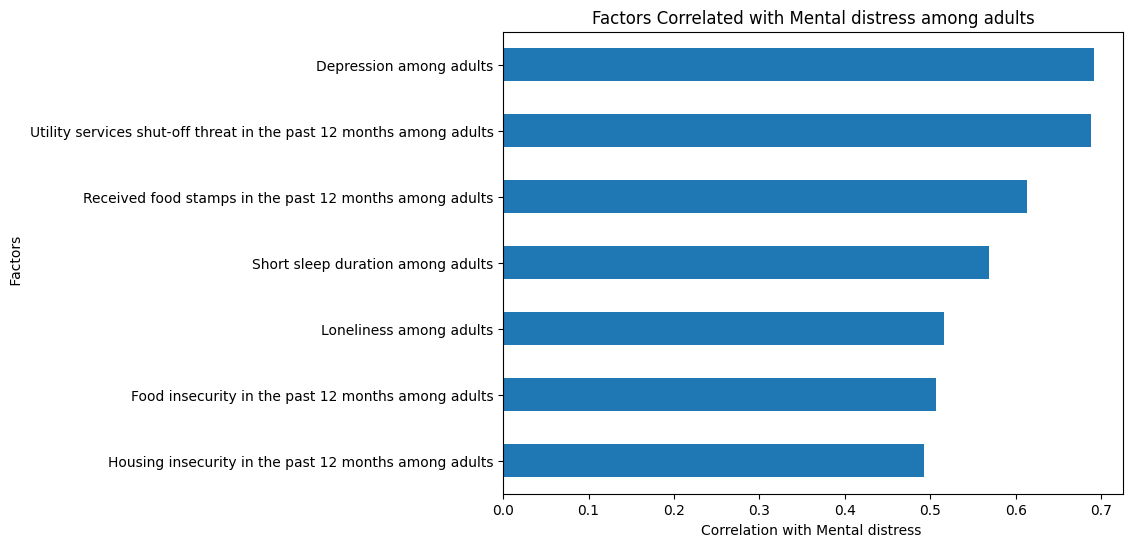

In [ ]:
mentalh_data.sort_values().plot(kind="barh", figsize=(8,6))

plt.title("Factors Correlated with Mental distress among adults")
plt.xlabel("Correlation with Mental distress ")
plt.ylabel(" Factors")

plt.show()

1. States with higher depression also have higher frequent mental distress rate
2. People with financial threat are more likely to experience mental distress.

In [ ]:
pivot_3 = pivot_3.fillna(pivot_3.mean(numeric_only=True))
pivot_3["financial_threat"] = (
    pivot_3["Housing insecurity in the past 12 months among adults"] +
    pivot_3["Utility services shut-off threat in the past 12 months among adults"]+
    pivot_3["Food insecurity in the past 12 months among adults"]+
    pivot_3["Received food stamps in the past 12 months among adults"]

)/4



X_1 = pivot_3[[
    "Depression among adults",
    "financial_threat"


]]
Y_1 = pivot_3["Frequent mental distress among adults"]

X_1_train, X_1_test, Y_1_train, Y_1_test = train_test_split(X_1, Y_1, test_size = 0.2, random_state=42)


print("Total rows:", len(pivot_3))
print("Training rows:", len(X_1_train))
print("Test rows:", len(X_1_test))


model = LinearRegression()
model.fit(X_1_train, Y_1_train)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

print("\nEquation:")
print(f"Mental_Distress = {model.intercept_:.3f} + ({model.coef_[0]:.3f} × Depression) + ({model.coef_[1]:.3f} × Financial Threat)")


Y_1_pred = model.predict(X_1_test)

print("\nActual values:")
print(Y_1_test.values)

print("\nPredicted values:")
print(Y_1_pred)


print("\nR2 Score:", r2_score(Y_1_test, Y_1_pred))
mse = mean_squared_error(Y_1_test, Y_1_pred)
print("Mean Squared Error:", mse)
print("Root Mean Squared Eror:",  np.sqrt(mse))


new_data = pd.DataFrame({
    "Depression among adults": [4],
    "financial_threat": [4]
})

new_prediction = model.predict(new_data)

print("\nPredicted Mental Distress for new data:")
print(f"{new_prediction[0]:.3f}")


Total rows: 1837
Training rows: 1469
Test rows: 368
Coefficients: [0.35750091 0.27249434]
Intercept: 5.416483973574518

Equation:
Mental_Distress = 5.416 + (0.358 × Depression) + (0.272 × Financial Threat)

Actual values:
[15.925      18.5        18.5        14.7        17.1        18.35
 14.25       18.8        17.2        17.         13.4        19.
 14.5        18.9        16.9        18.9        18.1        18.8
 19.2        16.5        18.         16.3        16.8        15.3
 17.7        14.9        16.4        16.9        15.4        16.1
 16.3        15.9        19.8        16.3        16.9        20.1
 16.93333333 13.2        17.65       15.5        13.2        16.8
 18.7875     17.4        17.2        16.7        17.96666667 15.5
 17.41666667 17.6        19.2        15.2        16.6        14.8
 18.3        18.         15.3        14.4        16.56       18.8
 19.5        19.         17.1        20.9        17.4        13.6
 16.5        18.9        17.3        15.6        20.

In [ ]:
#random forest


pivot_3 = pivot_3.fillna(pivot_3.mean(numeric_only=True))

pivot_3["financial_threat"] = (
    pivot_3["Housing insecurity in the past 12 months among adults"] +
    pivot_3["Utility services shut-off threat in the past 12 months among adults"] +
    pivot_3["Food insecurity in the past 12 months among adults"] +
    pivot_3["Received food stamps in the past 12 months among adults"]
) / 4

X_1 = pivot_3[[
    "Depression among adults",
    "financial_threat"
]]

Y_1 = pivot_3["Frequent mental distress among adults"]

X_1_train, X_1_test, Y_1_train, Y_1_test = train_test_split(
    X_1, Y_1, test_size=0.2, random_state=42
)

print("Total rows:", len(pivot_3))
print("Training rows:", len(X_1_train))
print("Test rows:", len(X_1_test))

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_1_train, Y_1_train)

Y_1_pred = rf_model.predict(X_1_test)

print("\nActual values:")
print(Y_1_test.values)

print("\nPredicted values:")
print(Y_1_pred)

print("\nR2 Score:", r2_score(Y_1_test, Y_1_pred))
mse = mean_squared_error(Y_1_test, Y_1_pred)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", np.sqrt(mse))

new_data = pd.DataFrame({
    "Depression among adults": [4],
    "financial_threat": [4]
})

new_prediction = rf_model.predict(new_data)

print("\nPredicted Mental Distress for new data:")
print(f"{new_prediction[0]:.3f}")



Total rows: 1837
Training rows: 1469
Test rows: 368

Actual values:
[15.925      18.5        18.5        14.7        17.1        18.35
 14.25       18.8        17.2        17.         13.4        19.
 14.5        18.9        16.9        18.9        18.1        18.8
 19.2        16.5        18.         16.3        16.8        15.3
 17.7        14.9        16.4        16.9        15.4        16.1
 16.3        15.9        19.8        16.3        16.9        20.1
 16.93333333 13.2        17.65       15.5        13.2        16.8
 18.7875     17.4        17.2        16.7        17.96666667 15.5
 17.41666667 17.6        19.2        15.2        16.6        14.8
 18.3        18.         15.3        14.4        16.56       18.8
 19.5        19.         17.1        20.9        17.4        13.6
 16.5        18.9        17.3        15.6        20.1        14.7
 16.         14.6        17.3        15.4        16.4        18.7
 17.7        17.8        17.6        19.5        16.35714286 17.9
 17.2   

In [ ]:
pivot_2 = pivot_2.fillna(pivot_2.mean(numeric_only=True))
pivot_2["financial_threat"] = (
    pivot_2["Housing insecurity in the past 12 months among adults"] +
    pivot_2["Utility services shut-off threat in the past 12 months among adults"]+
    pivot_2["Food insecurity in the past 12 months among adults"]+
    pivot_2["Received food stamps in the past 12 months among adults"]

)/4



X = pivot_2[[
    "Depression among adults",
    "financial_threat"


]]
Y = pivot_2["Frequent mental distress among adults"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=42)


print("Total rows:", len(pivot_2))
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))


model = LinearRegression()
model.fit(X_train, Y_train)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

print("\nEquation:")
print(f"Mental_Distress = {model.intercept_:.3f} + ({model.coef_[0]:.3f} × Depression) + ({model.coef_[1]:.3f} × Financial Threat)")


Y_pred = model.predict(X_test)

print("\nActual values:")
print(Y_test.values)

print("\nPredicted values:")
print(Y_pred)


print("\nR2 Score:", r2_score(Y_test, Y_pred))
mse = mean_squared_error(Y_test, Y_pred)
print("Mean Squared Error:", mse)
print("Root Mean Squared Eror:",  np.sqrt(mse))


new_data = pd.DataFrame({
    "Depression among adults": [4],
    "financial_threat": [4]
})

new_prediction = model.predict(new_data)

print("\nPredicted Mental Distress for new data:")
print(f"{new_prediction[0]:.3f}")




Total rows: 52
Training rows: 41
Test rows: 11
Coefficients: [0.31342386 0.27670656]
Intercept: 6.162857696868079

Equation:
Mental_Distress = 6.163 + (0.313 × Depression) + (0.277 × Financial Threat)

Actual values:
[17.80625    15.68181818 17.12180451 16.07272727 17.40750988 15.8609375
 16.70585259 15.51805556 18.99066667 16.03064516 17.00196078]

Predicted values:
[17.75580091 16.04594571 16.75270181 16.09563705 16.50542756 16.51407808
 16.67607193 16.12378138 18.15866192 15.64496144 16.3765657 ]

R2 Score: 0.7220638674012174
Mean Squared Error: 0.28292129481250605
Root Mean Squared Eror: 0.5319034638094643

Predicted Mental Distress for new data:
8.523
